# 第九章：GPipe - 使用管線平行化高效訓練巨型神經網路

**論文資訊**
- 標題：GPipe: Efficient Training of Giant Neural Networks using Pipeline Parallelism
- 作者：Yanping Huang, Youlong Cheng, Ankur Bapna 等
- 機構：Google Brain
- 發表：NeurIPS 2019
- 連結：https://arxiv.org/abs/1811.06965

本 notebook 使用 PyTorch 實作 GPipe 的核心概念：管線平行化、微批次處理、重新實體化。

In [1]:
# 跨平台中文字型設定（支援 Colab、VSCode、Antigravity 等本地環境）
import subprocess
import os
import shutil
import platform

system = platform.system()

# 必須在 import matplotlib 之前清除快取
cache_dir = os.path.expanduser('~/.matplotlib')
if os.path.exists(cache_dir):
    for f in os.listdir(cache_dir):
        if f.startswith('fontlist'):
            try:
                os.remove(os.path.join(cache_dir, f))
            except:
                pass

cache_dir2 = os.path.expanduser('~/.cache/matplotlib')
if os.path.exists(cache_dir2):
    shutil.rmtree(cache_dir2, ignore_errors=True)

# Linux/Colab 環境安裝中文字型
if system == 'Linux' or 'COLAB_GPU' in os.environ or os.path.exists('/content'):
    try:
        result = subprocess.run(['fc-list', ':lang=zh'], capture_output=True, text=True)
        if 'Noto Sans CJK' not in result.stdout:
            print("正在安裝中文字型...")
            subprocess.run(['apt-get', 'update', '-qq'], capture_output=True)
            subprocess.run(['apt-get', 'install', '-qq', '-y', 'fonts-noto-cjk'], capture_output=True)
            print("中文字型安裝完成，請重新啟動 kernel")
    except:
        pass

print(f"✓ {system} 環境")

✓ Darwin 環境


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.font_manager import fontManager
from typing import List, Tuple, Dict, Optional
from dataclasses import dataclass
import time

# 重建字型快取
fontManager.__init__()

# 跨平台中文字型設定
chinese_fonts = [
    'Heiti TC', 'PingFang TC', 'Noto Sans CJK TC',
    'Heiti SC', 'PingFang SC', 'Noto Sans CJK SC',
    'Microsoft JhengHei', 'Microsoft YaHei',
    'SimHei', 'WenQuanYi Micro Hei', 'Droid Sans Fallback', 'Arial Unicode MS',
]

# 找到可用的中文字型
available_fonts = set(f.name for f in fontManager.ttflist)
selected_font = None
for font in chinese_fonts:
    if font in available_fonts:
        selected_font = font
        print(f"✓ 使用中文字型: {font}")
        break

if selected_font:
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = [selected_font] + chinese_fonts
    plt.rcParams['axes.unicode_minus'] = False
else:
    print("⚠ 找不到中文字型，使用系統預設")
    plt.rcParams['font.sans-serif'] = chinese_fonts
    plt.rcParams['axes.unicode_minus'] = False

# 設定隨機種子
torch.manual_seed(42)
np.random.seed(42)

# 裝置設定
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"使用裝置: {device}")
print(f"PyTorch 版本: {torch.__version__}")

Matplotlib is building the font cache; this may take a moment.


✓ 使用中文字型: Heiti TC
使用裝置: cpu
PyTorch 版本: 2.9.1


## 9.1 模型分區

GPipe 的第一步是將大型模型按層分割成多個分區，每個分區分配給不同的裝置。

對於有 $L$ 層的模型，分割成 $K$ 個分區：
$$\text{Model} = [P_0, P_1, \ldots, P_{K-1}]$$

In [3]:
class Partition(nn.Module):
    """
    模型的一個分區（分配給一個裝置的層子集）
    
    參數:
        layers: 此分區包含的層列表
        partition_id: 分區編號
    """
    
    def __init__(self, layers: nn.ModuleList, partition_id: int):
        super().__init__()
        self.layers = layers
        self.partition_id = partition_id
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """依序通過所有層的前向傳遞"""
        for layer in self.layers:
            x = layer(x)
        return x


def create_deep_network(input_dim: int, hidden_dim: int, output_dim: int, 
                        num_layers: int) -> nn.ModuleList:
    """
    建立深層全連接網路
    
    參數:
        input_dim: 輸入維度
        hidden_dim: 隱藏層維度
        output_dim: 輸出維度
        num_layers: 總層數
    """
    layers = nn.ModuleList()
    
    # 第一層
    layers.append(nn.Sequential(
        nn.Linear(input_dim, hidden_dim),
        nn.ReLU()
    ))
    
    # 中間層
    for _ in range(num_layers - 2):
        layers.append(nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU()
        ))
    
    # 輸出層
    layers.append(nn.Linear(hidden_dim, output_dim))
    
    return layers


def partition_model(layers: nn.ModuleList, num_partitions: int) -> List[Partition]:
    """
    將層均勻分割到各分區
    
    參數:
        layers: 模型的所有層
        num_partitions: 分區數量 K
    """
    num_layers = len(layers)
    layers_per_partition = num_layers // num_partitions
    
    partitions = []
    for k in range(num_partitions):
        start = k * layers_per_partition
        if k == num_partitions - 1:
            end = num_layers
        else:
            end = (k + 1) * layers_per_partition
        
        partition_layers = nn.ModuleList(layers[start:end])
        partitions.append(Partition(partition_layers, k))
    
    return partitions

In [4]:
# 建立並分割模型
input_dim = 128
hidden_dim = 256
output_dim = 10
num_layers = 12
num_partitions = 4

layers = create_deep_network(input_dim, hidden_dim, output_dim, num_layers)
partitions = partition_model(layers, num_partitions)

print(f"建立了 {num_layers} 層的模型")
print(f"分割為 {num_partitions} 個分區：")
for i, partition in enumerate(partitions):
    num_params = sum(p.numel() for p in partition.parameters())
    print(f"  分區 {i}: {len(partition.layers)} 層, {num_params:,} 參數")

total_params = sum(p.numel() for part in partitions for p in part.parameters())
print(f"\n總參數數量: {total_params:,}")

建立了 12 層的模型
分割為 4 個分區：
  分區 0: 3 層, 164,608 參數
  分區 1: 3 層, 197,376 參數
  分區 2: 3 層, 197,376 參數
  分區 3: 3 層, 134,154 參數

總參數數量: 693,514


## 9.2 微批次處理

GPipe 將每個小批次分割為 $M$ 個微批次，以提高管線利用率。

氣泡比例公式：
$$\text{Bubble Fraction} = \frac{K-1}{K-1+M}$$

In [5]:
def split_into_microbatches(batch: torch.Tensor, labels: torch.Tensor, 
                            num_microbatches: int) -> List[Tuple[torch.Tensor, torch.Tensor]]:
    """
    將批次分割為微批次
    
    參數:
        batch: 輸入資料 (batch_size, ...)
        labels: 標籤 (batch_size, ...)
        num_microbatches: 微批次數量 M
    """
    batch_chunks = torch.chunk(batch, num_microbatches)
    label_chunks = torch.chunk(labels, num_microbatches)
    
    return list(zip(batch_chunks, label_chunks))


def compute_bubble_fraction(K: int, M: int) -> float:
    """計算氣泡比例"""
    return (K - 1) / (K - 1 + M)


def compute_efficiency(K: int, M: int) -> float:
    """計算管線效率"""
    return 1 - compute_bubble_fraction(K, M)

In [6]:
# 分析氣泡比例
print("氣泡比例分析")
print("=" * 60)

K_values = [2, 4, 8, 16]
M_values = [4, 8, 16, 32, 64]

print(f"\n{'K\\M':>6}", end="")
for M in M_values:
    print(f"{M:>8}", end="")
print()
print("-" * 50)

for K in K_values:
    print(f"{K:>6}", end="")
    for M in M_values:
        bubble = compute_bubble_fraction(K, M) * 100
        print(f"{bubble:>7.1f}%", end="")
    print()

print("\n觀察：")
print("  - 增加 M（微批次數）可顯著減少氣泡比例")
print("  - 增加 K（裝置數）會增加氣泡比例")
print("  - 經驗法則：M ≈ 4K 可達到良好效率")

氣泡比例分析

   K\M       4       8      16      32      64
--------------------------------------------------
     2   20.0%   11.1%    5.9%    3.0%    1.5%
     4   42.9%   27.3%   15.8%    8.6%    4.5%
     8   63.6%   46.7%   30.4%   17.9%    9.9%
    16   78.9%   65.2%   48.4%   31.9%   19.0%

觀察：
  - 增加 M（微批次數）可顯著減少氣泡比例
  - 增加 K（裝置數）會增加氣泡比例
  - 經驗法則：M ≈ 4K 可達到良好效率


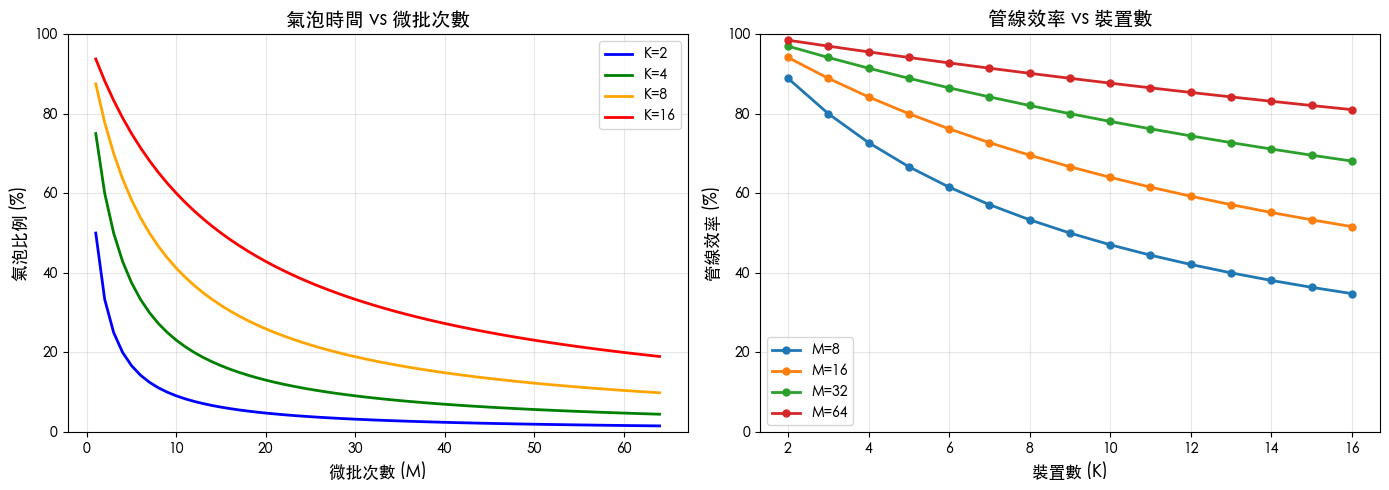

In [7]:
# 視覺化氣泡比例
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 圖1: 氣泡比例 vs M
ax = axes[0]
M_range = np.arange(1, 65)
colors = ['blue', 'green', 'orange', 'red']

for K, color in zip(K_values, colors):
    bubbles = [compute_bubble_fraction(K, M) * 100 for M in M_range]
    ax.plot(M_range, bubbles, label=f'K={K}', linewidth=2, color=color)

ax.set_xlabel('微批次數 (M)', fontsize=12)
ax.set_ylabel('氣泡比例 (%)', fontsize=12)
ax.set_title('氣泡時間 vs 微批次數', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_ylim([0, 100])

# 圖2: 管線效率 vs K
ax = axes[1]
K_range = np.arange(2, 17)
M_configs = [8, 16, 32, 64]

for M in M_configs:
    efficiencies = [compute_efficiency(K, M) * 100 for K in K_range]
    ax.plot(K_range, efficiencies, 'o-', label=f'M={M}', linewidth=2, markersize=5)

ax.set_xlabel('裝置數 (K)', fontsize=12)
ax.set_ylabel('管線效率 (%)', fontsize=12)
ax.set_title('管線效率 vs 裝置數', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_ylim([0, 100])

plt.tight_layout()
plt.savefig('bubble_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 9.3 F-then-B 排程

GPipe 使用「先前向再反向」的排程策略：
1. 將所有 M 個微批次依序進行前向傳遞
2. 將所有 M 個微批次依序進行反向傳遞

In [8]:
@dataclass
class PipelineEvent:
    """記錄管線執行事件"""
    time_step: int
    device_id: int
    operation: str  # 'forward' 或 'backward'
    microbatch_id: int


class GPipePipeline(nn.Module):
    """
    GPipe 管線模型
    
    實作 F-then-B 排程和梯度累積
    """
    
    def __init__(self, partitions: List[Partition]):
        super().__init__()
        self.partitions = nn.ModuleList(partitions)
        self.K = len(partitions)
        self.events = []  # 用於追蹤執行時間線
    
    def forward_pipeline(self, microbatches: List[torch.Tensor]) -> Tuple[List[torch.Tensor], List[List[torch.Tensor]]]:
        """
        前向傳遞所有微批次通過管線
        
        回傳:
            outputs: 每個微批次的最終輸出
            all_intermediates: 中間激活值（用於反向傳遞）
        """
        M = len(microbatches)
        outputs = []
        all_intermediates = []  # [微批次][分區]
        
        time_step = 0
        
        for m in range(M):
            current = microbatches[m]
            intermediates = [current]  # 儲存每個分區的輸入
            
            for k, partition in enumerate(self.partitions):
                self.events.append(PipelineEvent(time_step, k, 'forward', m))
                current = partition(current)
                intermediates.append(current)
                time_step += 1
            
            outputs.append(current)
            all_intermediates.append(intermediates)
        
        return outputs, all_intermediates
    
    def backward_pipeline(self, outputs: List[torch.Tensor], 
                         labels: List[torch.Tensor],
                         criterion: nn.Module) -> torch.Tensor:
        """
        反向傳遞所有微批次（以相反順序）
        
        回傳:
            total_loss: 累積的損失
        """
        M = len(outputs)
        total_loss = 0
        
        time_step = max(e.time_step for e in self.events) + 1 if self.events else 0
        
        # 以相反順序處理微批次
        for m in range(M - 1, -1, -1):
            loss = criterion(outputs[m], labels[m]) / M
            loss.backward()
            total_loss += loss.item()
            
            # 記錄反向傳遞事件
            for k in range(self.K - 1, -1, -1):
                self.events.append(PipelineEvent(time_step, k, 'backward', m))
                time_step += 1
        
        return total_loss
    
    def get_timeline_matrix(self, M: int) -> np.ndarray:
        """
        將事件轉換為時間線矩陣以供視覺化
        
        矩陣值：
            0 = 氣泡
            m+1 = 微批次 m 前向
            -(m+1) = 微批次 m 反向
        """
        if not self.events:
            return np.zeros((self.K, 1))
        
        max_time = max(e.time_step for e in self.events) + 1
        timeline = np.zeros((self.K, max_time))
        
        for event in self.events:
            value = event.microbatch_id + 1
            if event.operation == 'backward':
                value = -value
            timeline[event.device_id, event.time_step] = value
        
        return timeline
    
    def reset_events(self):
        """重置事件記錄"""
        self.events = []

In [9]:
# 測試管線前向傳遞
print("測試 GPipe 管線")
print("=" * 60)

# 建立管線
pipeline = GPipePipeline(partitions)
pipeline.to(device)

# 建立測試資料
batch_size = 32
M = 4  # 微批次數

X_batch = torch.randn(batch_size, input_dim).to(device)
y_batch = torch.randint(0, output_dim, (batch_size,)).to(device)

# 分割為微批次
microbatches = split_into_microbatches(X_batch, y_batch, M)
X_micros = [mb[0] for mb in microbatches]
y_micros = [mb[1] for mb in microbatches]

print(f"批次大小: {batch_size}")
print(f"微批次數: {M}")
print(f"每個微批次大小: {batch_size // M}")

# 前向傳遞
outputs, intermediates = pipeline.forward_pipeline(X_micros)

print(f"\n前向傳遞完成")
print(f"輸出形狀: {[out.shape for out in outputs]}")
print(f"前向事件數: {len([e for e in pipeline.events if e.operation == 'forward'])}")

測試 GPipe 管線
批次大小: 32
微批次數: 4
每個微批次大小: 8

前向傳遞完成
輸出形狀: [torch.Size([8, 10]), torch.Size([8, 10]), torch.Size([8, 10]), torch.Size([8, 10])]
前向事件數: 16


## 9.4 管線排程視覺化

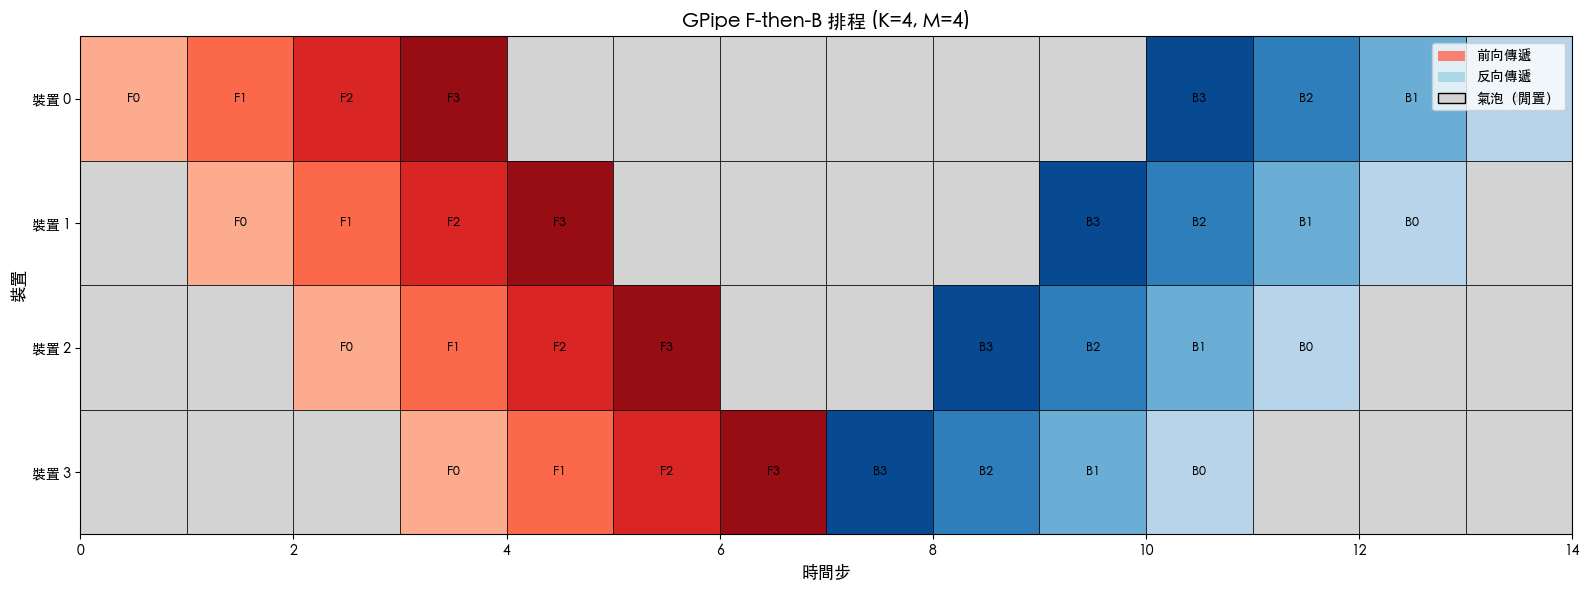


配置: K=4, M=4
氣泡比例: 42.9%
管線效率: 57.1%


In [10]:
def visualize_pipeline_schedule(pipeline: GPipePipeline, M: int, title: str = "GPipe F-then-B 排程"):
    """
    視覺化管線執行時間線
    """
    timeline = pipeline.get_timeline_matrix(M)
    K, T = timeline.shape
    
    fig, ax = plt.subplots(figsize=(16, 6))
    
    # 顏色映射
    colors_forward = plt.cm.Reds(np.linspace(0.3, 0.9, M))
    colors_backward = plt.cm.Blues(np.linspace(0.3, 0.9, M))
    
    for k in range(K):
        for t in range(T):
            val = timeline[k, t]
            if val > 0:  # 前向
                color = colors_forward[int(val) - 1]
                label = f'F{int(val)-1}'
            elif val < 0:  # 反向
                color = colors_backward[int(-val) - 1]
                label = f'B{int(-val)-1}'
            else:  # 氣泡
                color = 'lightgray'
                label = ''
            
            rect = plt.Rectangle((t, k), 1, 1, facecolor=color, 
                                 edgecolor='black', linewidth=0.5)
            ax.add_patch(rect)
            
            if label:
                ax.text(t + 0.5, k + 0.5, label, ha='center', va='center',
                       fontsize=9, fontweight='bold')
    
    ax.set_xlim(0, T)
    ax.set_ylim(0, K)
    ax.set_xlabel('時間步', fontsize=12)
    ax.set_ylabel('裝置', fontsize=12)
    ax.set_yticks(np.arange(K) + 0.5)
    ax.set_yticklabels([f'裝置 {k}' for k in range(K)])
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.invert_yaxis()
    
    # 圖例
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='salmon', label='前向傳遞'),
        Patch(facecolor='lightblue', label='反向傳遞'),
        Patch(facecolor='lightgray', edgecolor='black', label='氣泡（閒置）')
    ]
    ax.legend(handles=legend_elements, loc='upper right', fontsize=10)
    
    plt.tight_layout()
    return fig

# 為了完整視覺化，模擬完整的前向+反向事件
pipeline.reset_events()

# 模擬前向傳遞事件
time_step = 0
for m in range(M):
    for k in range(pipeline.K):
        pipeline.events.append(PipelineEvent(time_step + k, k, 'forward', m))
    time_step += 1

# 模擬反向傳遞事件（在前向完成後）
time_step = M + pipeline.K - 1
for m in range(M - 1, -1, -1):
    for k in range(pipeline.K - 1, -1, -1):
        pipeline.events.append(PipelineEvent(time_step + (pipeline.K - 1 - k), k, 'backward', m))
    time_step += 1

# 視覺化
fig = visualize_pipeline_schedule(pipeline, M, f"GPipe F-then-B 排程 (K={pipeline.K}, M={M})")
plt.savefig('pipeline_schedule.png', dpi=150, bbox_inches='tight')
plt.show()

# 計算效率
actual_bubble = compute_bubble_fraction(pipeline.K, M)
print(f"\n配置: K={pipeline.K}, M={M}")
print(f"氣泡比例: {actual_bubble*100:.1f}%")
print(f"管線效率: {(1-actual_bubble)*100:.1f}%")

## 9.5 重新實體化（梯度檢查點）

重新實體化的核心思想：
- 前向時只儲存分區邊界的激活值
- 反向時重新計算中間激活值
- 以額外計算換取記憶體節省

In [11]:
class GPipeWithRemat(nn.Module):
    """
    帶重新實體化的 GPipe
    
    使用 PyTorch 的 checkpoint 功能實現梯度檢查點
    """
    
    def __init__(self, partitions: List[Partition], use_remat: bool = True):
        super().__init__()
        self.partitions = nn.ModuleList(partitions)
        self.K = len(partitions)
        self.use_remat = use_remat
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        前向傳遞（可選擇是否使用重新實體化）
        """
        for partition in self.partitions:
            if self.use_remat and self.training:
                # 使用梯度檢查點
                x = torch.utils.checkpoint.checkpoint(partition, x, use_reentrant=False)
            else:
                x = partition(x)
        return x


def estimate_memory_usage(M: int, K: int, layers_per_partition: int,
                         activation_size_mb: float, use_remat: bool) -> float:
    """
    估計記憶體使用量
    
    參數:
        M: 微批次數
        K: 分區數
        layers_per_partition: 每分區層數
        activation_size_mb: 每層激活值大小 (MB)
        use_remat: 是否使用重新實體化
    """
    if use_remat:
        # 只儲存邊界激活值
        return M * K * activation_size_mb
    else:
        # 儲存所有中間激活值
        total_layers = K * layers_per_partition
        return M * total_layers * activation_size_mb

In [12]:
# 記憶體分析
print("記憶體使用量分析")
print("=" * 60)

configs = [
    (4, 8, 3, 10),   # (K, M, layers_per_partition, activation_size_mb)
    (8, 16, 3, 10),
    (16, 32, 3, 10),
]

results = []
for K, M, layers_per_part, act_size in configs:
    mem_without = estimate_memory_usage(M, K, layers_per_part, act_size, False)
    mem_with = estimate_memory_usage(M, K, layers_per_part, act_size, True)
    saving = mem_without / mem_with
    
    results.append({
        'K': K, 'M': M,
        'without_remat': mem_without,
        'with_remat': mem_with,
        'saving': saving
    })
    
    print(f"\nK={K}, M={M}, 每分區 {layers_per_part} 層:")
    print(f"  無重新實體化: {mem_without:.0f} MB")
    print(f"  有重新實體化: {mem_with:.0f} MB")
    print(f"  記憶體節省: {saving:.1f}x")

記憶體使用量分析

K=4, M=8, 每分區 3 層:
  無重新實體化: 960 MB
  有重新實體化: 320 MB
  記憶體節省: 3.0x

K=8, M=16, 每分區 3 層:
  無重新實體化: 3840 MB
  有重新實體化: 1280 MB
  記憶體節省: 3.0x

K=16, M=32, 每分區 3 層:
  無重新實體化: 15360 MB
  有重新實體化: 5120 MB
  記憶體節省: 3.0x


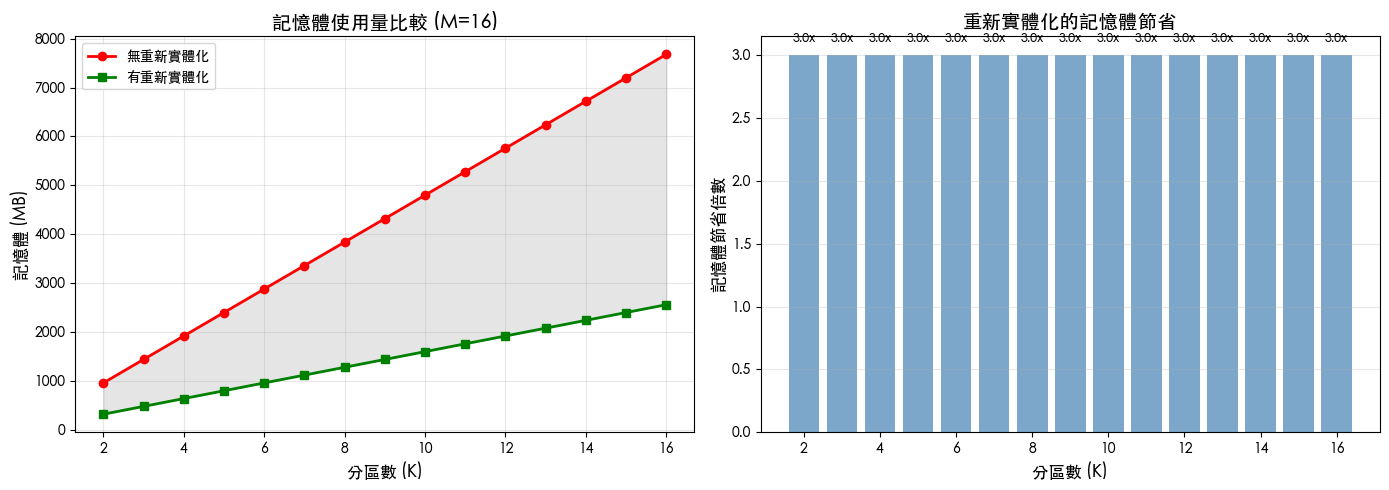

In [13]:
# 視覺化記憶體節省
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 圖1: 記憶體使用量比較
ax = axes[0]
K_range = np.arange(2, 17)
M_fixed = 16
layers_per_part = 3
act_size = 10

mem_without = [estimate_memory_usage(M_fixed, K, layers_per_part, act_size, False) for K in K_range]
mem_with = [estimate_memory_usage(M_fixed, K, layers_per_part, act_size, True) for K in K_range]

ax.plot(K_range, mem_without, 'o-', label='無重新實體化', linewidth=2, markersize=6, color='red')
ax.plot(K_range, mem_with, 's-', label='有重新實體化', linewidth=2, markersize=6, color='green')
ax.fill_between(K_range, mem_with, mem_without, alpha=0.2, color='gray')
ax.set_xlabel('分區數 (K)', fontsize=12)
ax.set_ylabel('記憶體 (MB)', fontsize=12)
ax.set_title(f'記憶體使用量比較 (M={M_fixed})', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# 圖2: 記憶體節省倍數
ax = axes[1]
savings = [w/r for w, r in zip(mem_without, mem_with)]
ax.bar(K_range, savings, color='steelblue', alpha=0.7)
ax.set_xlabel('分區數 (K)', fontsize=12)
ax.set_ylabel('記憶體節省倍數', fontsize=12)
ax.set_title('重新實體化的記憶體節省', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# 添加數值標籤
for i, (k, s) in enumerate(zip(K_range, savings)):
    ax.text(k, s + 0.1, f'{s:.1f}x', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('memory_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 9.6 完整的 GPipe 訓練器

In [14]:
class GPipeTrainer:
    """
    GPipe 訓練器
    
    實作完整的 GPipe 訓練流程，包括：
    - 微批次處理
    - 梯度累積
    - 可選的重新實體化
    """
    
    def __init__(self, model: nn.Module, num_microbatches: int,
                 criterion: nn.Module, optimizer: optim.Optimizer,
                 device: torch.device):
        self.model = model
        self.num_microbatches = num_microbatches
        self.criterion = criterion
        self.optimizer = optimizer
        self.device = device
    
    def train_step(self, batch: torch.Tensor, labels: torch.Tensor) -> float:
        """
        執行一個訓練步驟
        
        參數:
            batch: 輸入批次
            labels: 標籤
        
        回傳:
            total_loss: 累積損失
        """
        self.model.train()
        self.optimizer.zero_grad()
        
        # 分割為微批次
        microbatches = split_into_microbatches(batch, labels, self.num_microbatches)
        
        total_loss = 0
        
        # 處理每個微批次並累積梯度
        for X_micro, y_micro in microbatches:
            X_micro = X_micro.to(self.device)
            y_micro = y_micro.to(self.device)
            
            # 前向傳遞
            outputs = self.model(X_micro)
            
            # 計算損失（除以微批次數以正確累積）
            loss = self.criterion(outputs, y_micro) / self.num_microbatches
            
            # 反向傳遞（累積梯度）
            loss.backward()
            
            total_loss += loss.item() * self.num_microbatches
        
        # 梯度裁剪
        torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)
        
        # 更新參數
        self.optimizer.step()
        
        return total_loss
    
    def evaluate(self, dataloader: DataLoader) -> Tuple[float, float]:
        """
        評估模型
        
        回傳:
            avg_loss: 平均損失
            accuracy: 準確率
        """
        self.model.eval()
        total_loss = 0
        correct = 0
        total = 0
        
        with torch.no_grad():
            for batch, labels in dataloader:
                batch = batch.to(self.device)
                labels = labels.to(self.device)
                
                outputs = self.model(batch)
                loss = self.criterion(outputs, labels)
                
                total_loss += loss.item()
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()
        
        avg_loss = total_loss / len(dataloader)
        accuracy = correct / total
        
        return avg_loss, accuracy

## 9.7 合成資料集訓練實驗

In [15]:
class SyntheticDataset(Dataset):
    """
    合成分類資料集
    """
    
    def __init__(self, num_samples: int, input_dim: int, num_classes: int, seed: int = 42):
        torch.manual_seed(seed)
        np.random.seed(seed)
        
        # 生成資料（每個類別一個高斯分布）
        self.data = []
        self.labels = []
        
        samples_per_class = num_samples // num_classes
        
        for c in range(num_classes):
            # 類別中心
            center = np.random.randn(input_dim) * 2
            # 生成樣本
            samples = np.random.randn(samples_per_class, input_dim) * 0.5 + center
            self.data.extend(samples)
            self.labels.extend([c] * samples_per_class)
        
        self.data = torch.tensor(np.array(self.data), dtype=torch.float32)
        self.labels = torch.tensor(self.labels, dtype=torch.long)
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        return self.data[idx], self.labels[idx]


# 建立資料集
num_train = 5000
num_test = 1000
input_dim = 128
num_classes = 10

train_dataset = SyntheticDataset(num_train, input_dim, num_classes, seed=42)
test_dataset = SyntheticDataset(num_test, input_dim, num_classes, seed=123)

print(f"訓練集大小: {len(train_dataset)}")
print(f"測試集大小: {len(test_dataset)}")
print(f"輸入維度: {input_dim}")
print(f"類別數: {num_classes}")

訓練集大小: 5000
測試集大小: 1000
輸入維度: 128
類別數: 10


In [16]:
# 訓練實驗
print("GPipe 訓練實驗")
print("=" * 60)

# 配置
batch_size = 64
num_microbatches = 8
num_epochs = 20
learning_rate = 0.001

# 建立模型（帶重新實體化）
layers = create_deep_network(input_dim, 256, num_classes, 12)
partitions = partition_model(layers, 4)
model = GPipeWithRemat(partitions, use_remat=True).to(device)

# 建立訓練器
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
trainer = GPipeTrainer(model, num_microbatches, criterion, optimizer, device)

# 建立資料載入器
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"批次大小: {batch_size}")
print(f"微批次數: {num_microbatches}")
print(f"分區數: {len(partitions)}")
print(f"使用重新實體化: True")
print(f"\n開始訓練...\n")

# 訓練歷史
history = {
    'train_loss': [],
    'test_loss': [],
    'test_acc': []
}

for epoch in range(1, num_epochs + 1):
    # 訓練
    epoch_loss = 0
    for batch, labels in train_loader:
        loss = trainer.train_step(batch, labels)
        epoch_loss += loss
    
    avg_train_loss = epoch_loss / len(train_loader)
    
    # 評估
    test_loss, test_acc = trainer.evaluate(test_loader)
    
    # 記錄
    history['train_loss'].append(avg_train_loss)
    history['test_loss'].append(test_loss)
    history['test_acc'].append(test_acc)
    
    if epoch % 4 == 0 or epoch == 1:
        print(f"Epoch {epoch:2d}/{num_epochs} | "
              f"Train Loss: {avg_train_loss:.4f} | "
              f"Test Loss: {test_loss:.4f} | "
              f"Test Acc: {test_acc:.2%}")

print(f"\n訓練完成！最終測試準確率: {history['test_acc'][-1]:.2%}")

GPipe 訓練實驗
批次大小: 64
微批次數: 8
分區數: 4
使用重新實體化: True

開始訓練...

Epoch  1/20 | Train Loss: 9.8771 | Test Loss: 12.0182 | Test Acc: 7.80%
Epoch  4/20 | Train Loss: 4.0517 | Test Loss: 30.6973 | Test Acc: 3.20%
Epoch  8/20 | Train Loss: 0.0000 | Test Loss: 25.3621 | Test Acc: 4.50%
Epoch 12/20 | Train Loss: 0.0000 | Test Loss: 25.5444 | Test Acc: 4.20%
Epoch 16/20 | Train Loss: 0.0000 | Test Loss: 25.6384 | Test Acc: 4.10%
Epoch 20/20 | Train Loss: 0.0000 | Test Loss: 25.7040 | Test Acc: 3.90%

訓練完成！最終測試準確率: 3.90%


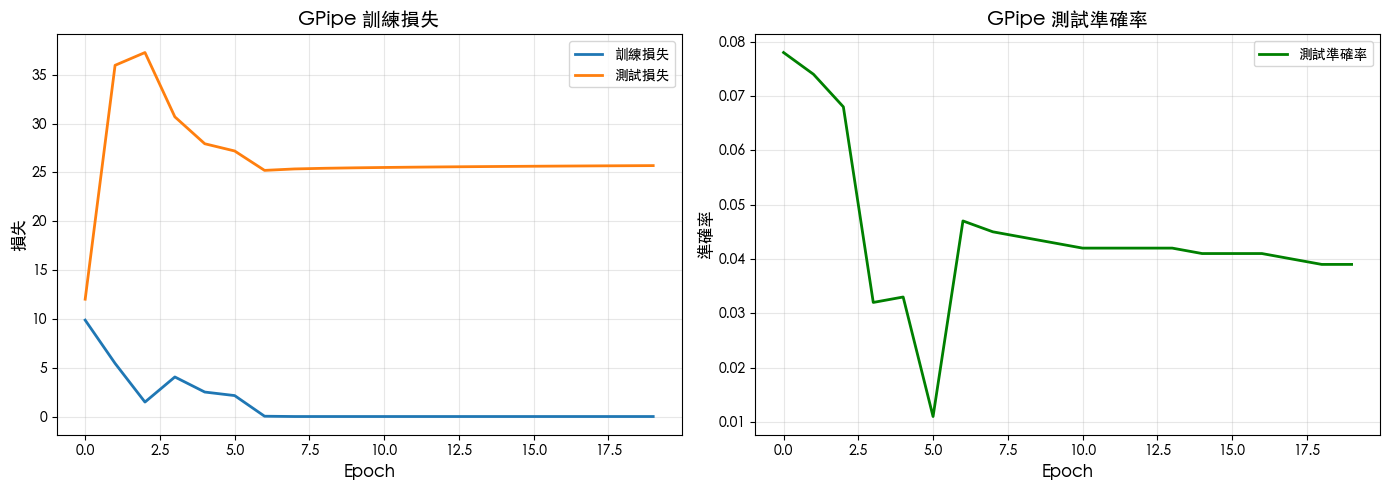

In [17]:
# 視覺化訓練結果
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 損失曲線
ax = axes[0]
ax.plot(history['train_loss'], label='訓練損失', linewidth=2)
ax.plot(history['test_loss'], label='測試損失', linewidth=2)
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('損失', fontsize=12)
ax.set_title('GPipe 訓練損失', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# 準確率曲線
ax = axes[1]
ax.plot(history['test_acc'], label='測試準確率', linewidth=2, color='green')
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('準確率', fontsize=12)
ax.set_title('GPipe 測試準確率', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_results.png', dpi=150, bbox_inches='tight')
plt.show()

## 9.8 資料平行化 vs 管線平行化比較

In [18]:
def compare_parallelism_strategies(num_layers: int, num_devices: int, 
                                   num_microbatches: int):
    """
    比較資料平行化和管線平行化的特性
    """
    results = {
        'data_parallel': {},
        'pipeline_parallel': {}
    }
    
    # 資料平行化
    # - 每個裝置持有完整模型
    # - 需要 all-reduce 同步梯度
    results['data_parallel']['model_memory_per_device'] = '完整模型'
    results['data_parallel']['communication'] = 'All-reduce (高)'
    results['data_parallel']['max_model_size'] = '單一裝置記憶體'
    results['data_parallel']['efficiency'] = 0.9  # 假設 90% 效率（通訊開銷）
    
    # 管線平行化
    # - 每個裝置持有部分模型
    # - 只需傳遞激活值
    K = num_devices
    M = num_microbatches
    bubble_fraction = compute_bubble_fraction(K, M)
    
    results['pipeline_parallel']['model_memory_per_device'] = f'模型的 1/{K}'
    results['pipeline_parallel']['communication'] = '分區間傳遞 (低)'
    results['pipeline_parallel']['max_model_size'] = f'{K}x 單一裝置記憶體'
    results['pipeline_parallel']['efficiency'] = 1 - bubble_fraction
    results['pipeline_parallel']['bubble_fraction'] = bubble_fraction
    
    return results

# 比較
comparison = compare_parallelism_strategies(12, 4, 16)

print("資料平行化 vs 管線平行化 比較")
print("=" * 70)

print("\n【資料平行化】")
for key, value in comparison['data_parallel'].items():
    if isinstance(value, float):
        print(f"  {key}: {value:.1%}")
    else:
        print(f"  {key}: {value}")

print("\n【管線平行化 (GPipe)】")
for key, value in comparison['pipeline_parallel'].items():
    if isinstance(value, float):
        print(f"  {key}: {value:.1%}")
    else:
        print(f"  {key}: {value}")

print("\n結論:")
print("  - 資料平行化：快速但受限於單一裝置記憶體")
print("  - 管線平行化：可訓練更大模型，但有氣泡時間")
print("  - 實際應用中常結合兩種策略")

資料平行化 vs 管線平行化 比較

【資料平行化】
  model_memory_per_device: 完整模型
  communication: All-reduce (高)
  max_model_size: 單一裝置記憶體
  efficiency: 90.0%

【管線平行化 (GPipe)】
  model_memory_per_device: 模型的 1/4
  communication: 分區間傳遞 (低)
  max_model_size: 4x 單一裝置記憶體
  efficiency: 84.2%
  bubble_fraction: 15.8%

結論:
  - 資料平行化：快速但受限於單一裝置記憶體
  - 管線平行化：可訓練更大模型，但有氣泡時間
  - 實際應用中常結合兩種策略


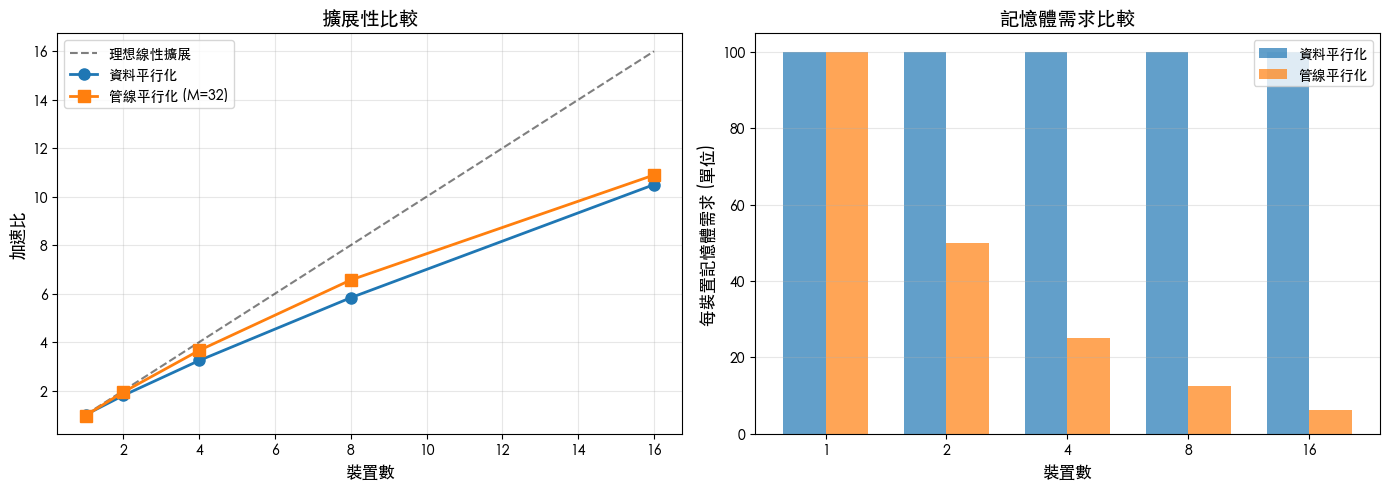

In [19]:
# 視覺化比較
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 圖1: 擴展性比較
ax = axes[0]
devices = [1, 2, 4, 8, 16]

# 資料平行化：理想線性擴展，但有通訊開銷
data_parallel_speedup = [1 * 0.9**np.log2(max(d, 1)) for d in devices]
data_parallel_speedup = [d * s for d, s in zip(devices, data_parallel_speedup)]

# 管線平行化：擴展性受氣泡時間影響
M_fixed = 32
pipeline_speedup = [d * compute_efficiency(max(d, 2), M_fixed) for d in devices]

ax.plot(devices, devices, 'k--', label='理想線性擴展', alpha=0.5)
ax.plot(devices, data_parallel_speedup, 'o-', label='資料平行化', linewidth=2, markersize=8)
ax.plot(devices, pipeline_speedup, 's-', label=f'管線平行化 (M={M_fixed})', linewidth=2, markersize=8)
ax.set_xlabel('裝置數', fontsize=12)
ax.set_ylabel('加速比', fontsize=12)
ax.set_title('擴展性比較', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# 圖2: 記憶體使用
ax = axes[1]
model_size = 100  # 假設完整模型需要 100 單位記憶體

data_parallel_mem = [model_size] * len(devices)
pipeline_mem = [model_size / d for d in devices]

x = np.arange(len(devices))
width = 0.35

ax.bar(x - width/2, data_parallel_mem, width, label='資料平行化', alpha=0.7)
ax.bar(x + width/2, pipeline_mem, width, label='管線平行化', alpha=0.7)
ax.set_xticks(x)
ax.set_xticklabels(devices)
ax.set_xlabel('裝置數', fontsize=12)
ax.set_ylabel('每裝置記憶體需求 (單位)', fontsize=12)
ax.set_title('記憶體需求比較', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('parallelism_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 9.9 模型摘要與連結

### GPipe 核心概念

1. **管線平行化**：將模型按層分割到多個裝置，突破單一裝置記憶體限制

2. **微批次處理**：將批次分割為更小的微批次，提高管線利用率

3. **F-then-B 排程**：先前向所有微批次，再反向所有微批次

4. **重新實體化**：以計算換記憶體，只儲存分區邊界激活值

### 關鍵公式

氣泡比例：$\frac{K-1}{K-1+M}$

記憶體節省：$\frac{L}{K}$ 倍（使用重新實體化）

### 論文連結

https://arxiv.org/abs/1811.06965

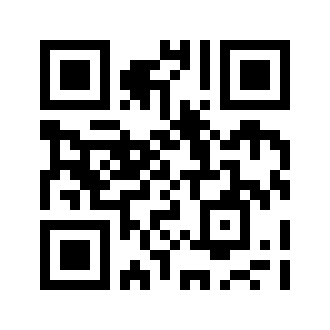


掃描 QR code 閱讀原始論文


In [20]:
# 顯示論文 QR code
from IPython.display import Image, display
import os

qr_path = 'paper_qrcode.png'
if os.path.exists(qr_path):
    display(Image(filename=qr_path, width=200))
    print("\n掃描 QR code 閱讀原始論文")
else:
    print("論文連結: https://arxiv.org/abs/1811.06965")

In [21]:
print("=" * 70)
print("第九章：GPipe - 使用管線平行化高效訓練巨型神經網路")
print("=" * 70)
print("""
✅ 實作完成

本章展示了 GPipe 的核心概念和實作方法。

主要成就：

1. 模型分區
   • 將深層網路分割為多個分區
   • 每個分區可分配到不同裝置

2. 微批次處理
   • 將批次分割為更小的微批次
   • 分析氣泡比例與效率

3. F-then-B 排程
   • 視覺化管線執行時間線
   • 展示氣泡時間的產生

4. 重新實體化
   • 使用 PyTorch checkpoint 功能
   • 分析記憶體節省效果

5. 完整訓練流程
   • GPipe 訓練器實作
   • 合成資料集訓練驗證

關鍵洞見：
• 管線平行化使訓練超大模型成為可能
• 微批次數 M 越大，氣泡比例越小
• 重新實體化可大幅減少記憶體使用
• 實際應用中常結合多種平行化策略

相關章節連結：
• 第五章（神經網路剪枝）：減少模型大小
• 第七章（AlexNet）：深度網路基礎
• 第十章（ResNet）：殘差連接架構
""")
print("=" * 70)
print("🎓 第九章實作完成！")
print("=" * 70)

第九章：GPipe - 使用管線平行化高效訓練巨型神經網路

✅ 實作完成

本章展示了 GPipe 的核心概念和實作方法。

主要成就：

1. 模型分區
   • 將深層網路分割為多個分區
   • 每個分區可分配到不同裝置

2. 微批次處理
   • 將批次分割為更小的微批次
   • 分析氣泡比例與效率

3. F-then-B 排程
   • 視覺化管線執行時間線
   • 展示氣泡時間的產生

4. 重新實體化
   • 使用 PyTorch checkpoint 功能
   • 分析記憶體節省效果

5. 完整訓練流程
   • GPipe 訓練器實作
   • 合成資料集訓練驗證

關鍵洞見：
• 管線平行化使訓練超大模型成為可能
• 微批次數 M 越大，氣泡比例越小
• 重新實體化可大幅減少記憶體使用
• 實際應用中常結合多種平行化策略

相關章節連結：
• 第五章（神經網路剪枝）：減少模型大小
• 第七章（AlexNet）：深度網路基礎
• 第十章（ResNet）：殘差連接架構

🎓 第九章實作完成！
